# Training RNN Model – Daily-Step Scheme

Scheme 2: A daily-step RNN that generates daily data via interpolation and uses an observation-masked loss.

**Key difference**: The loss is computed only at the true observation points (observed_mask=True), because data at all other time steps are obtained by interpolation.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pickle
import json
from pathlib import Path
from datetime import datetime
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
import shap
from n2o_pred.models import N2OPredictorRNN, count_parameters
from n2o_pred.data import create_dataloader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_SEED)

print(f'Random seed: {RANDOM_SEED}')


Using device: cpu
Random seed: 42


## 1. Load Data

In [2]:
data_dir = Path('../datasets/processed')

with open(data_dir / 'sequences_daily_step_train_processed.pkl', 'rb') as f:
    train_sequences = pickle.load(f)
with open(data_dir / 'sequences_daily_step_val_processed.pkl', 'rb') as f:
    val_sequences = pickle.load(f)

# Load scaler for inverse transformation
with open('../preprocessor/scalers.pkl', 'rb') as f:
    scalers = pickle.load(f)
target_scaler = scalers['target_daily']

print(f'Train: {len(train_sequences)}, Val: {len(val_sequences)}')
print(f'Example sequence has {train_sequences[0]["seq_length"]} days')
print(
    f'Observed points: {train_sequences[0]["observed_mask"].sum()} / {train_sequences[0]["seq_length"]}'
)


Train: 1212, Val: 135
Example sequence has 86 days
Observed points: 16 / 86


## 2. Model Initialization and Training Setup

In [3]:
BATCH_SIZE = 16
HIDDEN_SIZE = 64
NUM_LAYERS = 1
DROPOUT = 0.5
RNN_TYPE = 'LSTM'
LEARNING_RATE = 0.001
NUM_EPOCHS = 100
PATIENCE = 20

train_loader = create_dataloader(
    train_sequences, 'daily_step', BATCH_SIZE, shuffle=True, num_workers=0
)
val_loader = create_dataloader(
    val_sequences, 'daily_step', BATCH_SIZE, shuffle=False, num_workers=0
)

static_numeric_dim = train_sequences[0]['static_numeric'].shape[0]
static_categorical_dim = train_sequences[0]['static_categorical_encoded'].shape[0]
dynamic_numeric_dim = train_sequences[0]['dynamic_numeric'].shape[1]
fertilization_numeric_dim = train_sequences[0]['fertilization_numeric'].shape[1]
fertilization_categorical_dim = sum(
    train_sequences[0]['fertilization_categorical_encoded'][key].shape[1]
    for key in train_sequences[0]['fertilization_categorical_encoded']
)

print(
    f'Feature dims: static_num={static_numeric_dim}, static_cat={static_categorical_dim}, dynamic_num={dynamic_numeric_dim}, fert_num={fertilization_numeric_dim}, fert_cat={fertilization_categorical_dim}'
)

model = N2OPredictorRNN(
    static_numeric_dim=static_numeric_dim,
    static_categorical_dim=static_categorical_dim,
    dynamic_numeric_dim=dynamic_numeric_dim,
    fertilization_numeric_dim=fertilization_numeric_dim,
    fertilization_categorical_dim=fertilization_categorical_dim,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    rnn_type=RNN_TYPE,
).to(device)

print(f'Model parameters: {count_parameters(model):,}')

task_name = f'rnn_daily_{datetime.now().strftime("%Y%m%d_%H%M%S")}'
output_dir = Path(f'../outputs/{task_name}')
output_dir.mkdir(parents=True, exist_ok=True)

config = {
    'model_type': 'N2ORNN_DailyStep',
    'task_name': task_name,
    'random_seed': RANDOM_SEED,
    'hyperparameters': {
        'batch_size': BATCH_SIZE,
        'hidden_size': HIDDEN_SIZE,
        'num_layers': NUM_LAYERS,
        'dropout': DROPOUT,
        'rnn_type': RNN_TYPE,
        'learning_rate': LEARNING_RATE,
        'num_epochs': NUM_EPOCHS,
        'patience': PATIENCE,
    },
}
with open(output_dir / 'config.json', 'w') as f:
    json.dump(config, f, indent=2)

criterion = nn.MSELoss(reduction='none')
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

print(f'Output: {output_dir}')


Feature dims: static_num=7, static_cat=11, dynamic_num=4, fert_num=1, fert_cat=12
Model parameters: 45,121
Output: ../outputs/rnn_daily_20251117_175926


## 3. Training Function

In [4]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss, total_samples = 0, 0

    for batch in tqdm(dataloader, desc='Train', leave=False):
        static_feat = batch['static_features'].to(device)
        dynamic_feat = batch['dynamic_features'].to(device)
        targets = batch['targets'].to(device)
        lengths = batch['lengths']
        observed_masks = batch['observed_masks'].to(device)

        optimizer.zero_grad()
        predictions = model(static_feat, dynamic_feat, lengths)
        loss = criterion(predictions, targets)
        masked_loss = (loss * observed_masks.float()).sum() / observed_masks.sum()

        masked_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += masked_loss.item() * observed_masks.sum().item()
        total_samples += observed_masks.sum().item()

    return total_loss / total_samples


def inverse_symlog(y):
    """Inverse symlog transformation"""
    return np.sign(y) * (np.exp(np.abs(y)) - 1)


def evaluate(model, dataloader, criterion, device, scaler):
    """Evaluate model and return metrics on original scale"""
    model.eval()
    total_loss, total_samples = 0, 0
    all_preds, all_targets, all_targets_orig = [], [], []
    all_preds_orig = []  # Store predictions on original scale

    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Eval', leave=False):
            static_feat = batch['static_features'].to(device)
            dynamic_feat = batch['dynamic_features'].to(device)
            targets = batch['targets'].to(device)
            targets_orig = batch['targets_original']
            lengths = batch['lengths']
            observed_masks = batch['observed_masks'].to(device)
            predictions = model(static_feat, dynamic_feat, lengths)

            loss = criterion(predictions, targets)
            masked_loss = (loss * observed_masks.float()).sum() / observed_masks.sum()

            total_loss += masked_loss.item() * observed_masks.sum().item()
            total_samples += observed_masks.sum().item()

            for i in range(len(lengths)):
                obs_mask = observed_masks[i].cpu().numpy()
                obs_indices = np.where(obs_mask)[0]
                if len(obs_indices) > 0:
                    pred_seq = predictions[i, obs_indices].cpu().numpy()
                    
                    # Inverse transform predictions to original scale
                    pred_denorm = scaler.inverse_transform(pred_seq.reshape(-1, 1)).flatten()
                    pred_orig = inverse_symlog(pred_denorm)
                    
                    all_preds.append(pred_seq)  # Normalized predictions
                    all_preds_orig.append(pred_orig)  # Original scale predictions
                    all_targets.append(targets[i, obs_indices].cpu().numpy())
                    all_targets_orig.append(targets_orig[i, obs_indices].numpy())

    # Compute metrics on ORIGINAL scale
    all_preds_orig_flat = np.concatenate(all_preds_orig)
    all_targets_orig_flat = np.concatenate(all_targets_orig)
    
    rmse = np.sqrt(np.mean((all_preds_orig_flat - all_targets_orig_flat) ** 2))
    mae = np.mean(np.abs(all_preds_orig_flat - all_targets_orig_flat))
    
    # Calculate R² on original scale
    ss_res = np.sum((all_targets_orig_flat - all_preds_orig_flat) ** 2)
    ss_tot = np.sum((all_targets_orig_flat - np.mean(all_targets_orig_flat)) ** 2)
    r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0.0
    
    avg_loss = total_loss / total_samples

    return avg_loss, rmse, mae, r2, all_preds, all_targets, all_targets_orig, all_preds_orig


print('Training and evaluation functions defined')
print('KEY: Loss is computed only on observed points (observed_mask=True)')


Training and evaluation functions defined
KEY: Loss is computed only on observed points (observed_mask=True)


## 4. Training Loop

In [ ]:
history = {'train_loss': [], 'val_loss': [], 'val_rmse': [], 'val_mae': [], 'val_r2': [], 'lr': []}
best_val_loss = float('inf')
patience_counter = 0

print('Starting training...')
for epoch in range(NUM_EPOCHS):
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_rmse, val_mae, val_r2, _, _, _, _ = evaluate(model, val_loader, criterion, device, target_scaler)
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_rmse'].append(val_rmse)
    history['val_mae'].append(val_mae)
    history['val_r2'].append(val_r2)
    history['lr'].append(current_lr)

    print(
        f'Epoch {epoch + 1}: TrLoss={train_loss:.6f}, ValLoss={val_loss:.6f}, RMSE={val_rmse:.6f}, MAE={val_mae:.6f}, R²={val_r2:.6f}'
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(
            {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'val_loss': val_loss,
                'val_rmse': val_rmse,
                'val_mae': val_mae,
                'val_r2': val_r2,
            },
            output_dir / 'best_model.pth',
        )
        print('  ✓ Best model saved')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'Early stopping at epoch {epoch + 1}')
            break

print(f'Training completed! Best val loss: {best_val_loss:.6f}')

pd.DataFrame(history).to_csv(output_dir / 'training_log.csv', index=False)
print('Training log saved')


## 5. Visualization and Final Evaluation

NameError: name 'history' is not defined

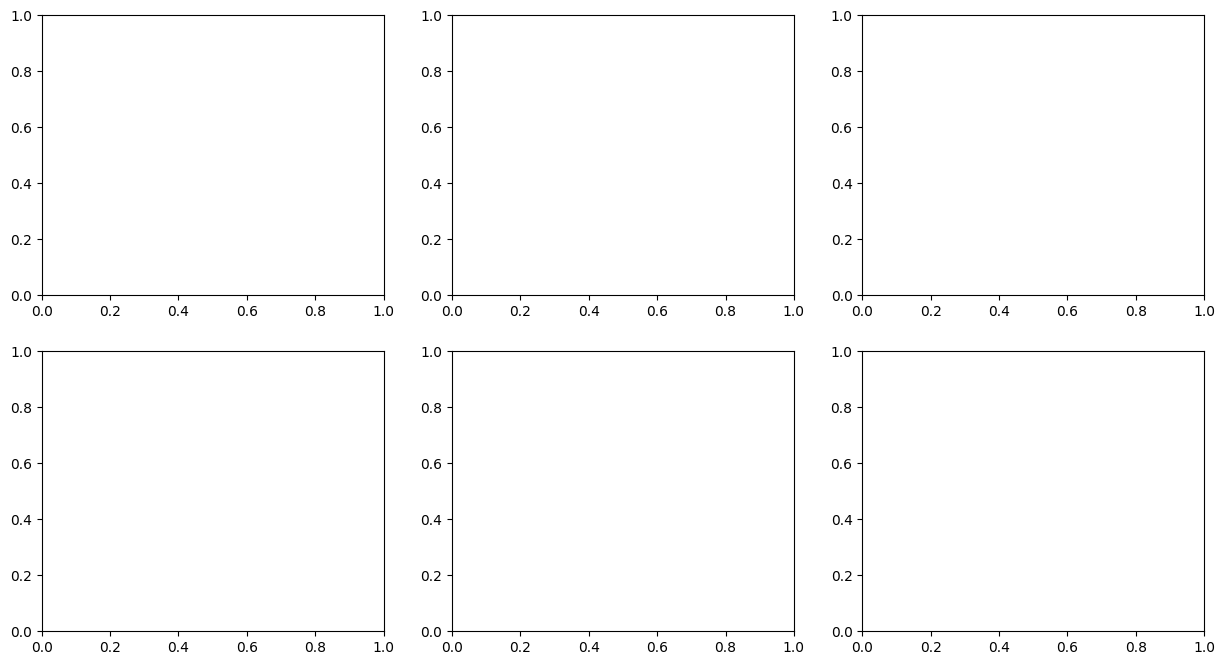

In [5]:
fig_dir = output_dir / 'figures'
fig_dir.mkdir(exist_ok=True)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes[0, 0].plot(history['train_loss'], label='Train')
axes[0, 0].plot(history['val_loss'], label='Val')
axes[0, 0].set_title('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(history['val_rmse'])
axes[0, 1].set_title('Val RMSE')
axes[0, 1].grid(True, alpha=0.3)

axes[0, 2].plot(history['val_mae'])
axes[0, 2].set_title('Val MAE')
axes[0, 2].grid(True, alpha=0.3)

axes[1, 0].plot(history['val_r2'])
axes[1, 0].set_title('Val R²')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(history['lr'])
axes[1, 1].set_title('Learning Rate')
axes[1, 1].set_yscale('log')
axes[1, 1].grid(True, alpha=0.3)

axes[1, 2].axis('off')  # Hide the last subplot

plt.tight_layout()
plt.savefig(fig_dir / 'training_curves.png', dpi=150)
plt.show()

checkpoint = torch.load(output_dir / 'best_model.pth', weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])

train_loss, train_rmse, train_mae, train_r2, train_preds, train_targets, train_targets_orig, train_preds_orig = (
    evaluate(model, train_loader, criterion, device, target_scaler)
)
val_loss, val_rmse, val_mae, val_r2, val_preds, val_targets, val_targets_orig, val_preds_orig = evaluate(
    model, val_loader, criterion, device, target_scaler
)

print(
    f'Final - Train Loss: {train_loss:.6f}, RMSE: {train_rmse:.6f}, MAE: {train_mae:.6f}, R²: {train_r2:.6f}'
)
print(
    f'Final - Val Loss: {val_loss:.6f}, RMSE: {val_rmse:.6f}, MAE: {val_mae:.6f}, R²: {val_r2:.6f}'
)

predictions = {
    'train': {
        'predictions': train_preds_orig,  # Original scale
        'targets': train_targets,  # Normalized scale
        'targets_original': train_targets_orig,  # Original scale
    },
    'val': {
        'predictions': val_preds_orig,  # Original scale
        'targets': val_targets,  # Normalized scale
        'targets_original': val_targets_orig  # Original scale
    },
    'metrics': {
        'train': {
            'loss': float(train_loss),
            'rmse': float(train_rmse),  # Computed on original scale
            'mae': float(train_mae),  # Computed on original scale
            'r2': float(train_r2),  # Computed on original scale
        },
        'val': {
            'loss': float(val_loss),
            'rmse': float(val_rmse),  # Computed on original scale
            'mae': float(val_mae),  # Computed on original scale
            'r2': float(val_r2),  # Computed on original scale
        },
    },
}

with open(output_dir / 'predictions.pkl', 'wb') as f:
    pickle.dump(predictions, f)

# Predictions vs True Values Scatter Plot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Use the original scale predictions (already inverse transformed)
train_preds_orig_scale = np.concatenate(train_preds_orig)
train_targets_orig_scale = np.concatenate(train_targets_orig)

axes[0].scatter(train_targets_orig_scale, train_preds_orig_scale, alpha=0.5, s=10)
axes[0].plot(
    [train_targets_orig_scale.min(), train_targets_orig_scale.max()],
    [train_targets_orig_scale.min(), train_targets_orig_scale.max()],
    'r--',
    lw=2,
)
axes[0].set_xlabel('True Daily N2O Fluxes', fontsize=11)
axes[0].set_ylabel('Predicted Daily N2O Fluxes', fontsize=11)
axes[0].set_title(f'Train Set (R²={train_r2:.3f})', fontsize=12)
axes[0].grid(True, alpha=0.3)

# Validation set
val_preds_orig_scale = np.concatenate(val_preds_orig)
val_targets_orig_scale = np.concatenate(val_targets_orig)

axes[1].scatter(val_targets_orig_scale, val_preds_orig_scale, alpha=0.5, s=10)
axes[1].plot(
    [val_targets_orig_scale.min(), val_targets_orig_scale.max()],
    [val_targets_orig_scale.min(), val_targets_orig_scale.max()],
    'r--',
    lw=2,
)
axes[1].set_xlabel('True Daily N2O Fluxes', fontsize=11)
axes[1].set_ylabel('Predicted Daily N2O Fluxes', fontsize=11)
axes[1].set_title(f'Validation Set (R²={val_r2:.3f})', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(fig_dir / 'predictions_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n{"=" * 60}')
print(f'All results saved to: {output_dir}')
print(f'{"=" * 60}')


## 6. SHAP Feature Importance Analysis


In [ ]:
print('Computing SHAP values for RNN-DailyStep model...')
print('Note: For RNN models, SHAP analysis is computed on time-averaged features')

# Sample validation sequences for SHAP
sample_size = min(100, len(val_sequences))
val_sample_indices = np.random.choice(len(val_sequences), sample_size, replace=False)

# Compute time-averaged features for SHAP analysis
avg_features = []
feature_names = []

# Get actual feature dimensions from data
first_seq = val_sequences[val_sample_indices[0]]
n_static_numeric = first_seq['static_numeric'].shape[0]
n_static_categorical = first_seq['static_categorical_encoded'].shape[0]
n_dynamic_numeric = first_seq['dynamic_numeric'].shape[1]
n_fert_numeric = first_seq['fertilization_numeric'].shape[1]
n_fert_cat_fert = first_seq['fertilization_categorical_encoded']['fertilization_class'].shape[1]
n_fert_cat_appl = first_seq['fertilization_categorical_encoded']['appl_class'].shape[1]

# Static features
static_numeric_names = ['Clay', 'CEC', 'BD', 'pH', 'SOC', 'TN', 'C/N'][:n_static_numeric]
static_categorical_names = [f'crop_class_{i} (encoded)' for i in range(n_static_categorical)]

# Dynamic features (averaged across time)
dynamic_numeric_names = ['Temp (avg)', 'Prec (avg)', 'ST (avg)', 'WFPS (avg)'][:n_dynamic_numeric]
fert_numeric_names = [f'fert_numeric_{i} (avg)' for i in range(n_fert_numeric)]
fert_cat_names_fert = [f'fertilization_class_{i} (avg)' for i in range(n_fert_cat_fert)]
fert_cat_names_appl = [f'appl_class_{i} (avg)' for i in range(n_fert_cat_appl)]

feature_names = (
    static_numeric_names
    + static_categorical_names
    + dynamic_numeric_names
    + fert_numeric_names
    + fert_cat_names_fert
    + fert_cat_names_appl
)

for idx in val_sample_indices:
    seq = val_sequences[idx]

    # Static features
    static = np.concatenate([seq['static_numeric'], seq['static_categorical_encoded']])

    # Time-averaged dynamic features (only at observed points)
    obs_mask = seq['observed_mask']
    
    # Check if there are any observed points
    if obs_mask.sum() > 0:
        avg_dyn = seq['dynamic_numeric'][obs_mask].mean(axis=0)
        avg_fert = seq['fertilization_numeric'][obs_mask].mean(axis=0).flatten()  # Ensure 1D
        avg_fert_cat_fert = seq['fertilization_categorical_encoded']['fertilization_class'][
            obs_mask
        ].mean(axis=0)
        avg_fert_cat_appl = seq['fertilization_categorical_encoded']['appl_class'][obs_mask].mean(
            axis=0
        )
    else:
        # If no observed points, use the mean of all points
        avg_dyn = seq['dynamic_numeric'].mean(axis=0)
        avg_fert = seq['fertilization_numeric'].mean(axis=0).flatten()
        avg_fert_cat_fert = seq['fertilization_categorical_encoded']['fertilization_class'].mean(axis=0)
        avg_fert_cat_appl = seq['fertilization_categorical_encoded']['appl_class'].mean(axis=0)

    combined = np.concatenate([static, avg_dyn, avg_fert, avg_fert_cat_fert, avg_fert_cat_appl])
    avg_features.append(combined)

X_sample = np.array(avg_features)
print(f'Total features: {len(feature_names)}, Sample shape: {X_sample.shape}')


# Create a simplified predictor wrapper
class SimplifiedRNNPredictor(nn.Module):
    def __init__(self, original_model, sample_sequences, sample_indices, device):
        super().__init__()
        self.original_model = original_model
        self.sample_sequences = [sample_sequences[i] for i in sample_indices]
        self.device = device

    def forward(self, x_batch):
        # x_batch: (batch, features) - already on CPU from SHAP
        # Convert to the model's device for fast inference
        x_batch_device = torch.FloatTensor(x_batch).to(self.device) if not isinstance(x_batch, torch.Tensor) else x_batch.to(self.device)
        
        predictions = []
        for i in range(x_batch_device.shape[0]):
            # Use the original sequence structure
            seq_idx = i % len(self.sample_sequences)
            seq = self.sample_sequences[seq_idx]

            static_dim = seq['static_numeric'].shape[0] + seq['static_categorical_encoded'].shape[0]
            static_feat = x_batch_device[i, :static_dim].unsqueeze(0)

            # Use original dynamic features - move to device directly
            dynamic_feat = torch.FloatTensor(seq['dynamic_numeric']).unsqueeze(0).to(self.device)
            fert_num = torch.FloatTensor(seq['fertilization_numeric']).unsqueeze(0).to(self.device)
            fert_cat_fert = torch.FloatTensor(
                seq['fertilization_categorical_encoded']['fertilization_class']
            ).unsqueeze(0).to(self.device)
            fert_cat_appl = torch.FloatTensor(
                seq['fertilization_categorical_encoded']['appl_class']
            ).unsqueeze(0).to(self.device)

            dynamic_combined = torch.cat(
                [dynamic_feat, fert_num, fert_cat_fert, fert_cat_appl], dim=2
            )

            with torch.no_grad():
                pred = self.original_model(static_feat, dynamic_combined, None)
                # Average over observed points only
                obs_mask = torch.BoolTensor(seq['observed_mask']).to(self.device)
                pred_obs = pred[0, obs_mask]
                predictions.append(pred_obs.mean().item())

        return torch.FloatTensor(predictions)  # Return on CPU for SHAP


wrapped_model = SimplifiedRNNPredictor(model, val_sequences, val_sample_indices, device)

# Use KernelExplainer
print('Using KernelExplainer (this may take a few minutes)...')
background_data = shap.sample(X_sample, min(50, len(X_sample)))
explainer = shap.KernelExplainer(
    lambda x: wrapped_model(torch.FloatTensor(x).to(device)).cpu().detach().numpy(), background_data
)

# Compute SHAP values for a smaller sample
shap_sample_size = min(20, len(X_sample))
shap_values = explainer.shap_values(X_sample[:shap_sample_size])

print(f'SHAP values computed for {shap_sample_size} samples')

# Calculate mean absolute SHAP values
mean_abs_shap = np.abs(shap_values).mean(axis=0)

# Create SHAP importance DataFrame (raw)
shap_importance_raw = pd.DataFrame(
    {'feature': feature_names[: len(mean_abs_shap)], 'shap_importance': mean_abs_shap}
).sort_values('shap_importance', ascending=False)

print('\nTop 15 Features by SHAP Importance (Raw):')
print(shap_importance_raw.head(15))

# Save raw SHAP importance
shap_importance_raw.to_csv(output_dir / 'shap_importance_raw.csv', index=False)


# Aggregate SHAP importance for categorical features
def aggregate_shap_importance(shap_importance_df):
    """Aggregate SHAP importance for one-hot encoded categorical features"""
    aggregated = {}
    
    categorical_features = ['crop_class', 'fertilization_class', 'appl_class']
    
    for _, row in shap_importance_df.iterrows():
        feat_name = row['feature']
        importance = row['shap_importance']
        
        is_categorical = False
        for cat_feat in categorical_features:
            if cat_feat in feat_name and ('(encoded)' in feat_name or '(avg)' in feat_name):
                # This is a categorical feature, aggregate to original name
                if cat_feat not in aggregated:
                    aggregated[cat_feat] = 0
                aggregated[cat_feat] += importance
                is_categorical = True
                break
        
        if not is_categorical:
            aggregated[feat_name] = importance
    
    aggregated_df = pd.DataFrame(
        [{'feature': feat, 'shap_importance': imp} for feat, imp in aggregated.items()]
    ).sort_values('shap_importance', ascending=False)
    
    return aggregated_df


shap_importance_agg = aggregate_shap_importance(shap_importance_raw)

print('\n' + '=' * 60)
print('Aggregated SHAP Importance (Categorical features combined):')
print('=' * 60)
print(shap_importance_agg)

# Save aggregated SHAP importance
shap_importance_agg.to_csv(output_dir / 'shap_importance_aggregated.csv', index=False)

# Visualize SHAP importance (both raw and aggregated)
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Left: Top 15 raw features
shap_importance_raw.head(15).plot(
    x='feature', y='shap_importance', kind='barh', ax=axes[0], color='steelblue', legend=False
)
axes[0].set_xlabel('Mean |SHAP value|', fontsize=11)
axes[0].set_title('Top 15 Raw Features by SHAP Importance (RNN-DailyStep)', fontsize=12)
axes[0].invert_yaxis()

# Right: All aggregated features
shap_importance_agg.plot(
    x='feature', y='shap_importance', kind='barh', ax=axes[1], color='coral', legend=False
)
axes[1].set_xlabel('Mean |SHAP value|', fontsize=11)
axes[1].set_title('Aggregated SHAP Importance (RNN-DailyStep)', fontsize=12)
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(fig_dir / 'shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Save SHAP values
shap_data = {
    'shap_values': shap_values,
    'X_sample': X_sample[:shap_sample_size],
    'feature_names': feature_names[: len(mean_abs_shap)],
}
with open(output_dir / 'shap_values.pkl', 'wb') as f:
    pickle.dump(shap_data, f)

print(f'\nSHAP analysis complete! Results saved to {output_dir}')
